<a href="https://colab.research.google.com/github/kfartem434-png/MN_Kapusta/blob/main/%D0%9B%D0%912_2_%D0%9A%D0%B0%D0%BF%D1%83%D1%81%D1%82%D0%B0_3_12_%D0%91%D0%B5%D1%81%D1%82%D1%81%D0%B5%D0%BB%D0%B5%D1%80%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#!pip install pandas --upgrade

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os

In [4]:
print(np.__version__)
print(pd.__version__)

2.1.3
2.2.3


In [19]:
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")
df = pd.read_csv(os.path.join(path,"bestsellers with categories.csv"))
print(len(df))
print(df.shape)
print(df.columns.values)
df.head(10)

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
550
(550, 7)
['Name' 'Author' 'User Rating' 'Reviews' 'Price' 'Year' 'Genre']


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11,2011,Fiction
6,A Game of Thrones / A Clash of Kings / A Storm...,George R. R. Martin,4.7,19735,30,2014,Fiction
7,A Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15,2017,Fiction
8,"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,5983,3,2018,Non Fiction
9,A Man Called Ove: A Novel,Fredrik Backman,4.6,23848,8,2016,Fiction


Датафрейм має розмірність 550 рядків та 7 стовпців.

Стовпці зберігають такі дані:

**Name**: назва книги;

**Author**: автор книги;

**User Rating**: рейтинг книги;

**Reviews**: кількість відгуків;

**Price**: ціна книги;

**Year**: рік видання;

**Genre**: жанр книги, може бути `Fiction` або `Non Fiction`.

In [20]:
print("Дуплікати рядків: \n\n",df.loc[df.duplicated()],end="\n\n")
print("Дуплікати назв: \n\n",df.loc[df["Name"].duplicated()][["Name","Year"]],end="\n\n")
print("Дуплікати назв та років видання: \n\n",
  df.loc[df[["Name","Year"]].duplicated(keep=False)][["Name","Year","Author"]],
  end="\n\n"
)
print("Кількість NA: \n\n",df.isna().sum(),end="\n\n")

Дуплікати рядків: 

 Empty DataFrame
Columns: [Name, Author, User Rating, Reviews, Price, Year, Genre]
Index: []

Дуплікати назв: 

                                                   Name  Year
10                           A Man Called Ove: A Novel  2017
21                         All the Light We Cannot See  2015
33                                            Becoming  2019
36                            Between the World and Me  2016
41            Brown Bear, Brown Bear, What Do You See?  2019
..                                                 ...   ...
543                                             Wonder  2016
544                                             Wonder  2017
547  You Are a Badass: How to Stop Doubting Your Gr...  2017
548  You Are a Badass: How to Stop Doubting Your Gr...  2018
549  You Are a Badass: How to Stop Doubting Your Gr...  2019

[199 rows x 2 columns]

Дуплікати назв та років видання: 

                                                   Name  Year  \
367       

Датасет не має пропусків значень, але має дуплікати назв книг з однаковими роками видання.

In [24]:
df.drop_duplicates(subset=["Name","Year"],inplace=True)

In [25]:
df["Genre"] = df["Genre"].map({"Fiction": 1,"Non Fiction": 0})

In [26]:
df.rename(columns={"User Rating": "User_Rating"},inplace=True)

Видаляємо дуплікати назв з однаковими роками та замінюємо категоріальні дані стовпчика `Genre` на числові дані: `Fiction`: 1, `Non Fiction`: 0.

In [27]:
df.describe()

,User_Rating,Reviews,Price,Year,Genre
count,547.000000,547.000000,547.000000,547.000000,547.000000
mean,4.617550,11846.945155,13.106033,2014.005484,0.435101
std,0.227309,11621.690067,10.868162,3.171237,0.496224
min,3.300000,37.000000,0.000000,2009.000000,0.000000
25%,4.500000,4025.000000,7.000000,2011.000000,0.000000
50%,4.700000,8491.000000,11.000000,2014.000000,0.000000
75%,4.800000,17017.000000,16.000000,2017.000000,1.000000
max,4.900000,87841.000000,105.000000,2019.000000,1.000000


З числового опису датасету можна визначити:

**Мінімальний рейтинг книги:** 3,3;

**Максимальний рейтинг книги:** 4,9;

**Середній рейтинг книг:** 4,6;

**Середня вартість книг:** 10,8 доларів;

**Відсоток художньої літератури:** 43%.

In [43]:
top_books_by_year = df[["Name","Year","User_Rating","Reviews"]].groupby("Year").max()
top_books_by_year.head(11)

,Name,User_Rating,Reviews
Year,,,
2009,Where the Wild Things Are,4.8,19720
2010,Women Food and God: An Unexpected Path to Almo...,4.8,32122
2011,What to Expect When You're Expecting,4.9,32122
2012,Winter of the World: Book Two of the Century T...,4.9,57271
2013,Wonder,4.9,57271
2014,Wonder,4.9,57271
2015,Wonder,4.9,79446
2016,You Are a Badass: How to Stop Doubting Your Gr...,4.9,79446
2017,You Are a Badass: How to Stop Doubting Your Gr...,4.9,29442


У таблиці вище наведені книги з найвищим рейтингом за кожен рік.

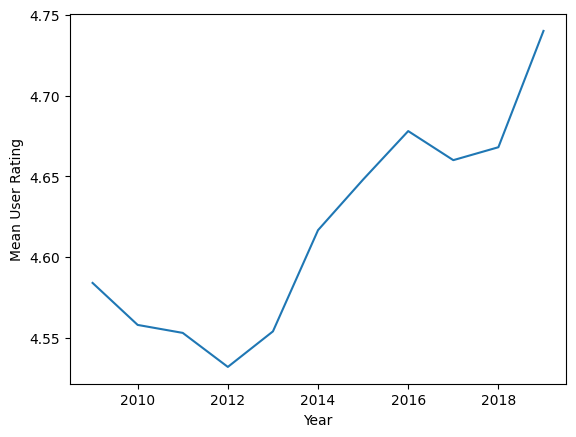

In [12]:
mean_ratings_by_year = df[["Year","User_Rating"]].groupby("Year").agg(
  Mean_User_Rating=("User_Rating","mean")
)
mean_ratings_by_year.plot(kind="line",y="Mean_User_Rating",legend=False)
plt.ylabel("Mean User Rating")
plt.show()

З графіку можна побачити, що існує тренд збільшення середнього рейтингу книг в часі.

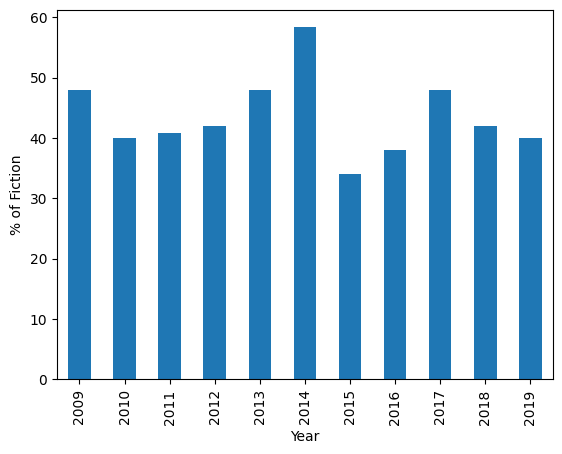

Коефіцієнт кореляції: 

 nan



In [50]:
fiction_percentage_by_year = df[["Year","Genre"]].groupby("Year").agg(
  Fiction_Percent=("Genre",lambda x: np.mean(x) * 100)
)
fiction_percentage_by_year.plot(kind="bar",y="Fiction_Percent",legend=False)
plt.ylabel("% of Fiction")
plt.show()

Графік показує, що відсоток художньої літератури в топ 50 по роках залишається в районі 40%, що співпадає з числовим описом даних.

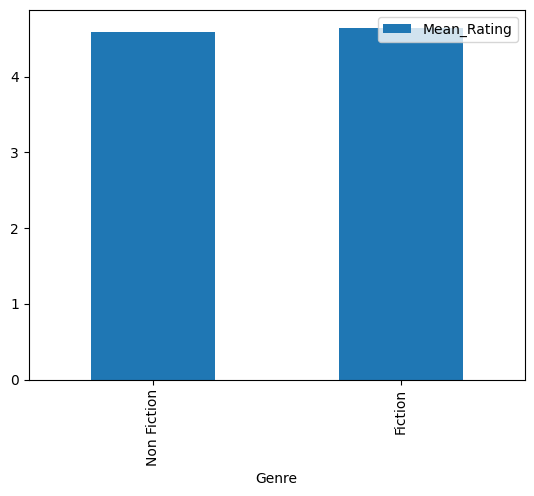

In [57]:
mean_rating_by_genre = df[["Genre","User_Rating"]].groupby("Genre").agg(Mean_Rating=("User_Rating","mean"))
mean_rating_by_genre.rename(index={0: "Non Fiction",1: "Fiction"},inplace=True)
mean_rating_by_genre.head(2)
mean_rating_by_genre.plot(kind="bar",y="Mean_Rating")
plt.show()

Художня література має в середньому вищий рейтинг за нехудожню.

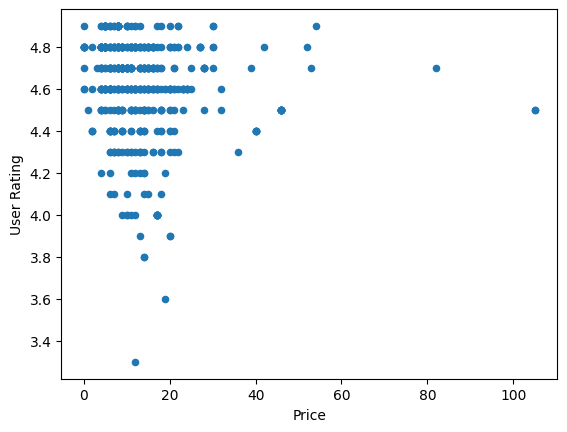

Коефіцієнт кореляції: 

 -0.13286658785334238



In [56]:
df[["Price","User_Rating"]].plot(kind="scatter",x="Price",y="User_Rating")
plt.ylabel("User Rating")
plt.show()
print("Коефіцієнт кореляції: \n\n",df["Price"].corr(df["User_Rating"]),end="\n\n")

Згідно коефіцієнту кореляції, існує слабка негативна кореляція між ціною книги та її рейтингом.

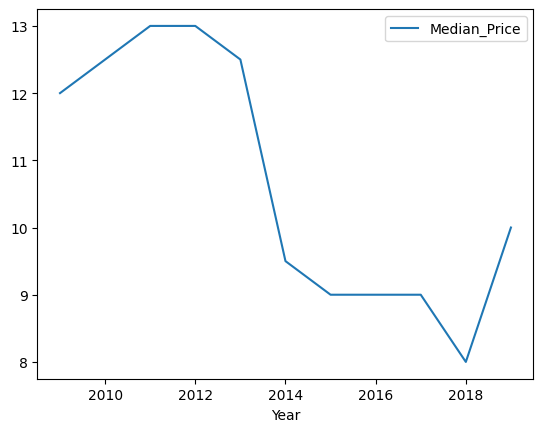

In [71]:
median_price_by_year = df[["Year","Price"]].groupby("Year").agg(Median_Price=("Price","median"))
median_price_by_year.plot(kind="line",y="Median_Price")
plt.show()

З графіку можна побачити існування негативної кореляції між часом та медіаною ціни книг.